# Descrição do Projeto

A empresa Taxi Corrida Maluca coletou dados históricos sobre pedidos de táxi nos aeroportos. Para atrair mais motoristas durante o horário de pico, precisamos prever a quantidade de pedidos de táxi para a próxima hora.
Construa um modelo para tal predição.

A métrica REQM no conjunto de teste não deve ser superior a 48.

## Instruções do projeto

1. Faça download dos dados e faça uma nova amostragem em uma hora.
2. Analise os dados
3. Treine diferentes modelos com diferentes hiperparâmetros. A amostra de teste deve ser 10% do conjunto de dados inicial.
4. Teste os dados usando a amostra de teste e forneça uma conclusão.

## Descrição dos dados

Os dados são armazenados no arquivo `taxi.csv`. O número de pedidos está na coluna `num_orders`.

## Preparação

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.seasonal import seasonal_decompose

RANDOM_STATE = 12345

Carreguei os dados já definindo a coluna `datetime` como índice e convertendo-a para o tipo `datetime64`.

In [2]:
data = pd.read_csv('/datasets/taxi.csv', index_col=[0], parse_dates=[0])

data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


Antes de qualquer transformação, verifiquei três condições básicas de uma série temporal: se o índice está em ordem cronológica, se há registros duplicados e se há valores ausentes.

In [3]:
print('Índice em ordem cronológica:', data.index.is_monotonic_increasing)
print('Índices duplicados:', data.index.duplicated().sum())
print('Valores ausentes:', data.isna().sum().sum())
print('Período coberto:', data.index.min(), 'até', data.index.max())

Índice em ordem cronológica: True
Índices duplicados: 0
Valores ausentes: 0
Período coberto: 2018-03-01 00:00:00 até 2018-08-31 23:50:00


O índice já está ordenado, não há duplicatas nem valores ausentes. Ainda assim apliquei `sort_index()`, já que todo o restante da análise depende da ordenação.

Os dados originais têm frequência de 10 minutos. Como o objetivo é prever o número de pedidos da próxima hora, reamostramos a série em intervalos de uma hora, somando os pedidos dentro de cada intervalo.

In [4]:
data.sort_index(inplace=True)
data = data.resample('1h').sum()

print('Formato após a reamostragem:', data.shape)
display(data.head())

Formato após a reamostragem: (4416, 1)


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43


## Análise

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


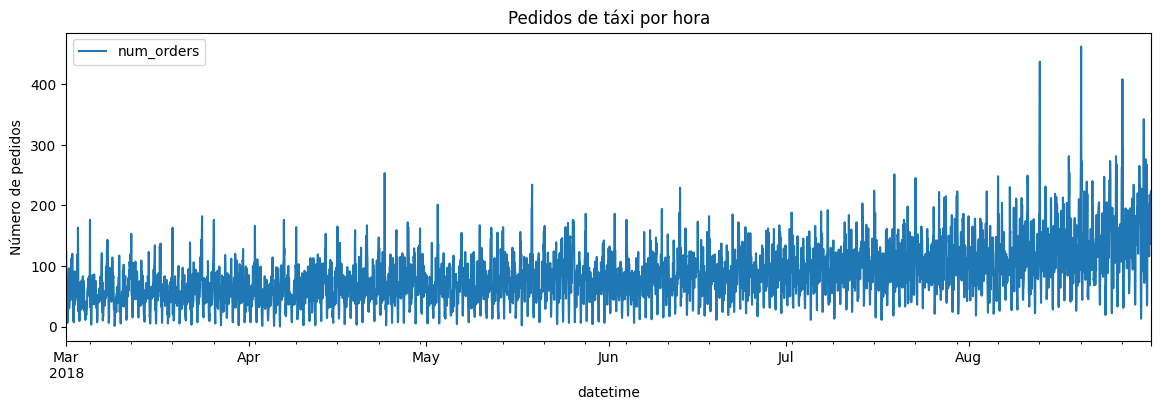

In [5]:
display(data.describe())

data.plot(figsize=(14, 4), title='Pedidos de táxi por hora')
plt.ylabel('Número de pedidos')
plt.show()

A série cobre 6 meses (março a agosto de 2018) e ficou com 4416 registros horários. A média é de aproximadamente 84 pedidos por hora, com máximo de 462 e mínimo de 0. Horas sem nenhum pedido existem, mas são raras: o primeiro quartil já está em 54 pedidos.

O gráfico da série completa tem oscilações de alta frequência que dificultam a leitura. Separamos a série em tendência, sazonalidade e resíduos para enxergar os padrões por trás do ruído.

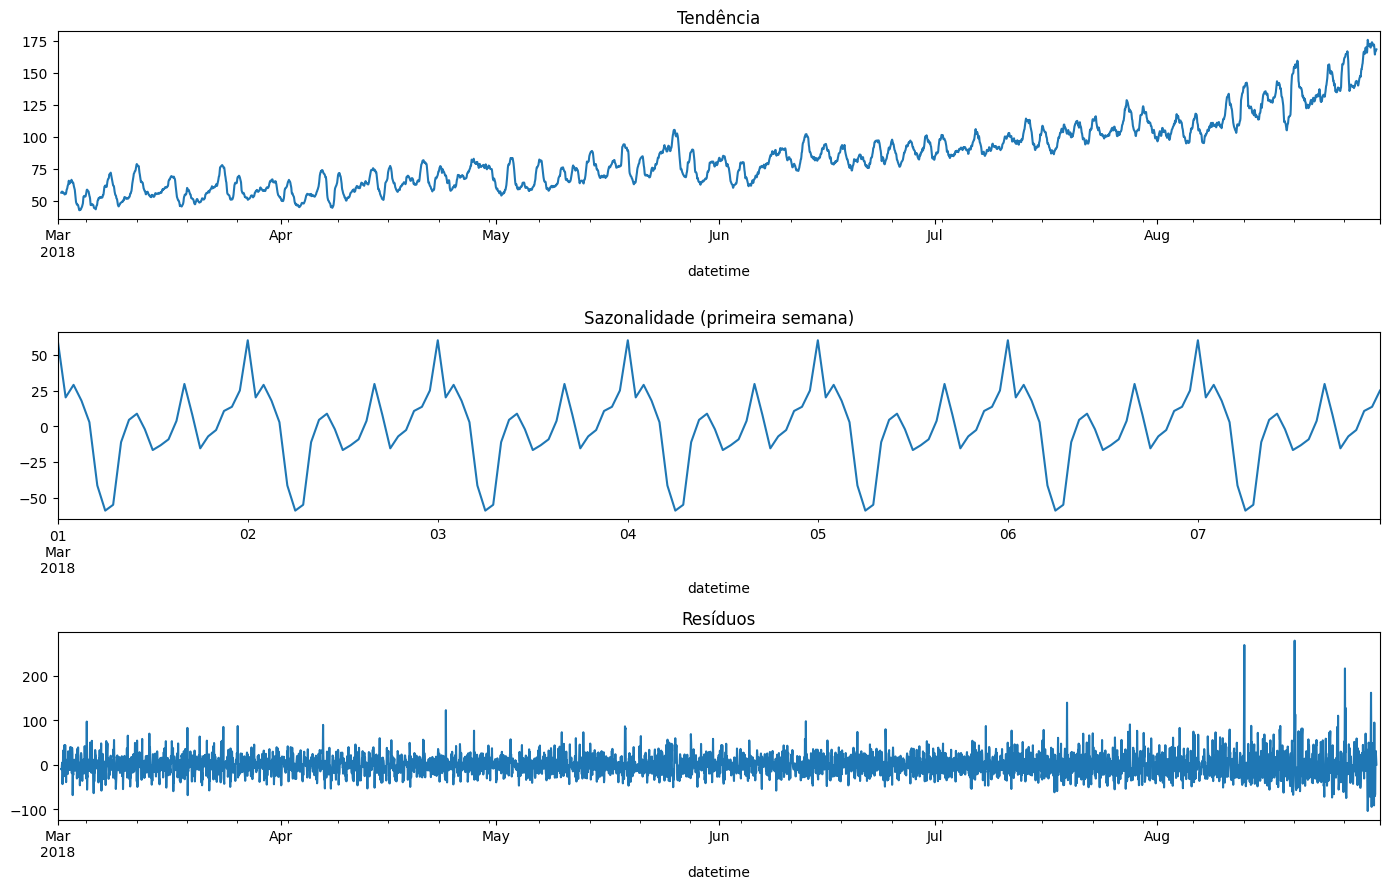

In [6]:
decomposed = seasonal_decompose(data['num_orders'])

plt.figure(figsize=(14, 9))
plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Tendência')
plt.subplot(312)
decomposed.seasonal['2018-03-01':'2018-03-07'].plot(ax=plt.gca())
plt.title('Sazonalidade (primeira semana)')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Resíduos')
plt.tight_layout()
plt.show()

A decomposição mostra uma tendência de crescimento ao longo dos 6 meses e um componente sazonal que se repete a cada 24 horas. O recorte da sazonalidade em uma única semana é necessário porque, no gráfico completo, o ciclo diário fica compactado demais para ser legível.

O gráfico abaixo quantifica esses efeitos.

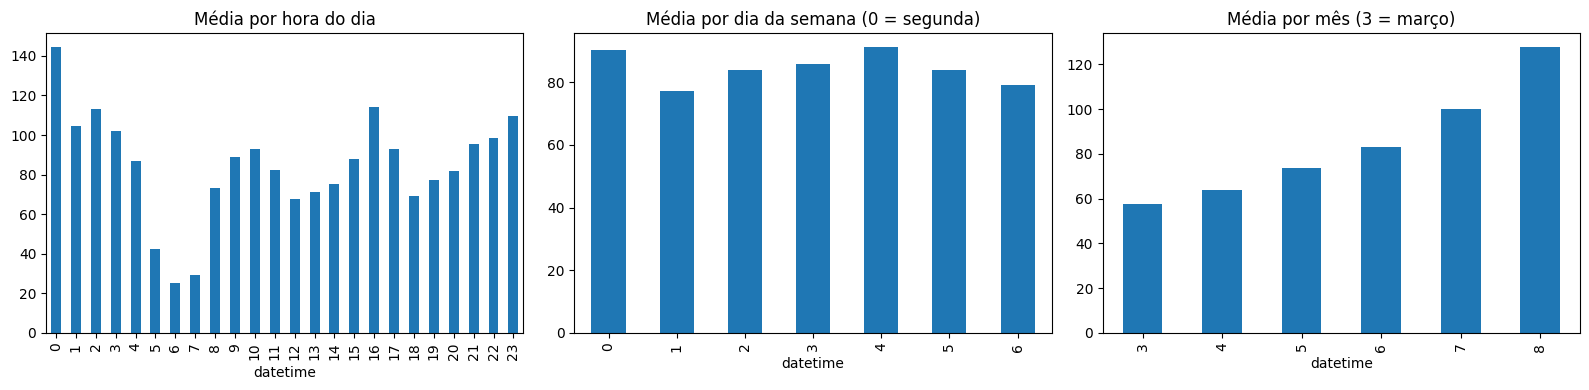

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

data.groupby(data.index.hour)['num_orders'].mean().plot(
    kind='bar', ax=axes[0], title='Média por hora do dia'
)
data.groupby(data.index.dayofweek)['num_orders'].mean().plot(
    kind='bar', ax=axes[1], title='Média por dia da semana (0 = segunda)'
)
data.groupby(data.index.month)['num_orders'].mean().plot(
    kind='bar', ax=axes[2], title='Média por mês (3 = março)'
)

plt.tight_layout()
plt.show()

Padrão horário: o pico ocorre à meia-noite, com média de 144 pedidos, e a demanda permanece alta pela madrugada. O vale acontece às 6h da manhã, com média de 25 pedidos, quase 6 vezes menos que o pico. Há um segundo pico, menor, às 16h. Esse comportamento faz sentido para pedidos em aeroportos, onde chegadas noturnas concentram a procura por táxi.

Padrão semanal: as diferenças entre os dias são pequenas, variando de 77 a 91 pedidos em média, com segunda e sexta acima e terça abaixo.

Padrão mensal: a média sobe de 57 pedidos em março para 128 em agosto, mais que o dobro. O crescimento é o efeito mais forte da série.

Como o número de pedidos de uma hora depende das horas anteriores e da posição no ciclo diário, construímos características de calendário, defasagens (*lags*) e média móvel.

### Criação de características

In [8]:
def make_features(df, max_lag, rolling_mean_size):
    """Adiciona características de calendário, defasagens e média móvel à série."""
    df = df.copy()

    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['day'] = df.index.day
    df['month'] = df.index.month

    for lag in range(1, max_lag + 1):
        df[f'lag_{lag}'] = df['num_orders'].shift(lag)

    df['rolling_mean'] = (
        df['num_orders'].shift().rolling(rolling_mean_size).mean()
    )

    return df

O `shift()` antes do `rolling()` é obrigatório: sem ele, a média móvel de uma linha incluiria o próprio valor que queremos prever, o que seria vazamento de dados.

As defasagens vão até 72 horas (3 dias). Isso permite ao modelo capturar tanto a dependência imediata (`lag_1`) quanto o mesmo horário em dias anteriores (`lag_24`, `lag_48`, `lag_72`).

A janela da média móvel é de 168 horas (7 dias), maior que a defasagem máxima. Essa escolha não é arbitrária: se a janela fosse menor ou igual a `max_lag`, a média móvel seria uma combinação linear exata das defasagens já presentes (a média de 24 horas anteriores é exatamente a média de `lag_1` a `lag_24`). A coluna seria redundante, a matriz de características ficaria singular e a regressão linear se tornaria numericamente instável. Com 168 horas, a média móvel resume o nível de demanda da última semana e carrega informação que as 72 defasagens não contêm.

In [9]:
MAX_LAG = 72
ROLLING_MEAN_SIZE = 168

data_features = make_features(data, MAX_LAG, ROLLING_MEAN_SIZE)
display(data_features.head())

,num_orders,hour,dayofweek,day,month,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_64,lag_65,lag_66,lag_67,lag_68,lag_69,lag_70,lag_71,lag_72,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,0,3,1,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,1,3,1,3,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,2,3,1,3,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,3,1,3,71.0,85.0,124.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,4,3,1,3,66.0,71.0,85.0,124.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Divisão em treinamento e teste

As características são criadas antes da divisão, para que as primeiras linhas do conjunto de teste possam usar os últimos valores do treinamento como defasagens. Isso não gera vazamento, porque cada linha só olha para o próprio passado.

A divisão usa `shuffle=False`. Embaralhar uma série temporal permitiria ao modelo usar o futuro para prever o passado. O conjunto de teste corresponde aos 10% finais da série, como pede o projeto.

As primeiras linhas do treinamento têm valores ausentes nas defasagens e na média móvel, já que não existem dados anteriores a elas. Essas linhas são removidas.

In [10]:
train, test = train_test_split(data_features, shuffle=False, test_size=0.1)
train = train.dropna()

features_train = train.drop(columns=['num_orders'])
target_train = train['num_orders']
features_test = test.drop(columns=['num_orders'])
target_test = test['num_orders']

print('Treinamento:', features_train.shape, '|', train.index.min(), 'a', train.index.max())
print('Teste:      ', features_test.shape, '|', test.index.min(), 'a', test.index.max())

Treinamento: (3806, 77) | 2018-03-08 00:00:00 a 2018-08-13 13:00:00
Teste:       (442, 77) | 2018-08-13 14:00:00 a 2018-08-31 23:00:00


Uma verificação rápida confirma que a matriz de características está bem condicionada. Um número de condição muito alto (acima de 10¹⁵) indicaria colunas redundantes e soluções instáveis para a regressão linear.

In [11]:
matriz = np.c_[np.ones(len(features_train)), features_train.values]
print('Número de condição da matriz de características:', f'{np.linalg.cond(matriz):.2e}')

Número de condição da matriz de características: 4.68e+03


## Treinamento

Para escolher os hiperparâmetros usamos `TimeSeriesSplit`, uma validação cruzada que respeita a ordem temporal: cada divisão treina no passado e valida no futuro imediato, nunca o contrário. A validação cruzada padrão (`KFold`) embaralharia os períodos e produziria uma estimativa otimista demais.

A métrica de seleção é a REQM, a mesma exigida pelo projeto.

Os quatro modelos e suas grades de hiperparâmetros são definidos em uma única estrutura e percorridos pelo mesmo laço, o que evita repetir código.

In [12]:
tscv = TimeSeriesSplit(n_splits=5)

modelos = [
    ('Regressão Linear', LinearRegression(), {}),
    (
        'Árvore de Decisão',
        DecisionTreeRegressor(random_state=RANDOM_STATE),
        {'max_depth': [5, 8, 12, 16], 'min_samples_leaf': [1, 5, 10]},
    ),
    (
        'Floresta Aleatória',
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [100], 'max_depth': [10, 16], 'min_samples_leaf': [1, 5]},
    ),
    (
        'LightGBM',
        LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
        {
            'n_estimators': [100, 300],
            'learning_rate': [0.05, 0.1],
            'num_leaves': [15, 31],
        },
    ),
]

resultados = []

for nome, modelo, grade in modelos:
    inicio = time.time()
    busca = GridSearchCV(
        modelo, grade, cv=tscv, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    busca.fit(features_train, target_train)
    duracao = time.time() - inicio

    resultados.append(
        {
            'Modelo': nome,
            'Melhores hiperparâmetros': busca.best_params_,
            'REQM (validação cruzada)': round(-busca.best_score_, 2),
            'Tempo de treinamento (s)': round(duracao, 1),
            'estimador': busca.best_estimator_,
        }
    )
    print(f'{nome}: concluído em {duracao:.1f}s')

Regressão Linear: concluído em 1.2s
Árvore de Decisão: concluído em 2.1s
Floresta Aleatória: concluído em 50.2s
LightGBM: concluído em 8.9s


In [13]:
tabela = (
    pd.DataFrame(resultados)
    .drop(columns=['estimador'])
    .sort_values('REQM (validação cruzada)')
    .reset_index(drop=True)
)

display(tabela)

,Modelo,Melhores hiperparâmetros,REQM (validação cruzada),Tempo de treinamento (s)
0,LightGBM,"{'learning_rate': 0.1, 'n_estimators': 100, 'n...",23.90,8.9
1,Regressão Linear,{},24.19,1.2
2,Floresta Aleatória,"{'max_depth': 16, 'min_samples_leaf': 1, 'n_es...",24.43,50.2
3,Árvore de Decisão,"{'max_depth': 5, 'min_samples_leaf': 10}",28.16,2.1


O LightGBM obtém a menor REQM na validação cruzada. A regressão linear e a floresta aleatória ficam bem próximas dele, com diferença inferior a 0,6 pedido. A árvore de decisão isolada é o único modelo claramente pior.

A proximidade entre a regressão linear e os modelos de ensemble indica que boa parte do sinal da série é linear nas defasagens. O ganho dos modelos mais complexos vem da parte não linear, que é pequena neste caso.

O tempo de treinamento separa bem os modelos: a floresta aleatória leva várias vezes mais tempo que o LightGBM para chegar a um resultado pior. Como o LightGBM vence tanto em qualidade quanto em custo, ele é o escolhido para a avaliação final.

In [14]:
melhor = min(resultados, key=lambda r: r['REQM (validação cruzada)'])
melhor_modelo = melhor['estimador']

print('Modelo selecionado:', melhor['Modelo'])
print('Hiperparâmetros:', melhor['Melhores hiperparâmetros'])

Modelo selecionado: LightGBM
Hiperparâmetros: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 15}


## Testando

Antes de avaliar o modelo, estabelecemos duas previsões de referência para o teste de sanidade. A primeira prevê sempre a média do conjunto de treinamento. A segunda prevê que a próxima hora terá o mesmo número de pedidos da hora anterior, que é a previsão ingênua clássica em séries temporais. Um modelo só é útil se ficar abaixo das duas.

In [15]:
pred_media = np.ones(len(target_test)) * target_train.mean()

pred_anterior = target_test.shift()
pred_anterior.iloc[0] = target_train.iloc[-1]


def reqm(objetivo, predicao):
    """Calcula a raiz do erro quadrático médio."""
    return mean_squared_error(objetivo, predicao) ** 0.5


predicao_teste = melhor_modelo.predict(features_test)

print('REQM - referência (média constante):', round(reqm(target_test, pred_media), 2))
print('REQM - referência (valor anterior): ', round(reqm(target_test, pred_anterior), 2))
print('REQM - LightGBM no conjunto de teste:', round(reqm(target_test, predicao_teste), 2))

REQM - referência (média constante): 83.98
REQM - referência (valor anterior):  58.86
REQM - LightGBM no conjunto de teste: 39.07


O modelo fica bem abaixo das duas referências. A tabela seguinte compara o desempenho de todos os modelos treinados no conjunto de teste.

In [16]:
tabela_teste = pd.DataFrame(
    [
        {
            'Modelo': r['Modelo'],
            'REQM (validação cruzada)': r['REQM (validação cruzada)'],
            'REQM (teste)': round(reqm(target_test, r['estimador'].predict(features_test)), 2),
        }
        for r in resultados
    ]
).sort_values('REQM (teste)').reset_index(drop=True)

display(tabela_teste)

,Modelo,REQM (validação cruzada),REQM (teste)
0,LightGBM,23.90,39.07
1,Floresta Aleatória,24.43,40.58
2,Regressão Linear,24.19,41.99
3,Árvore de Decisão,28.16,47.54


O LightGBM continua na frente e a árvore de decisão continua atrás. A regressão linear e a floresta aleatória trocam de posição entre a validação cruzada e o teste, o que era previsível: a diferença entre as duas na validação cruzada era de apenas 0,24 pedido, dentro da margem de variação entre conjuntos. Os quatro modelos ficam abaixo do limite de 48, mas o LightGBM tem a maior margem.

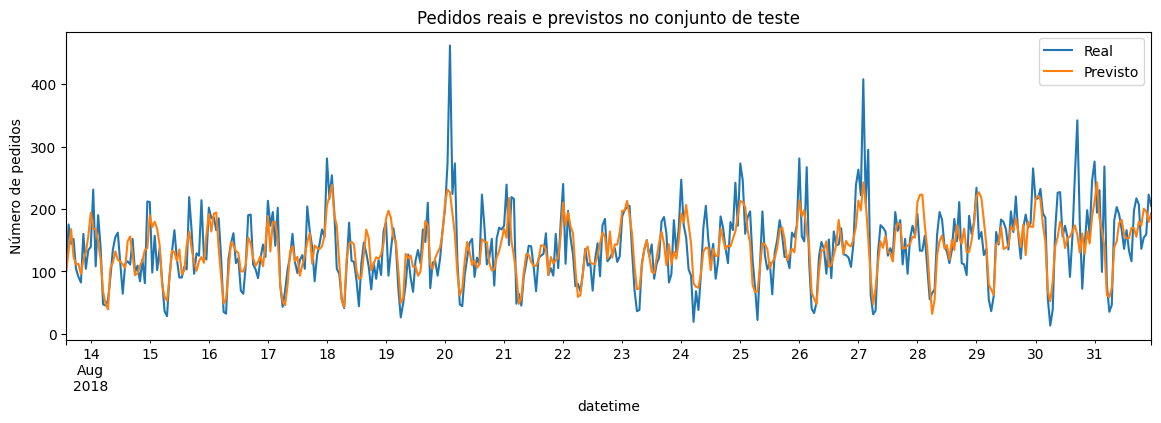

In [17]:
plt.figure(figsize=(14, 4))
target_test.plot(label='Real')
pd.Series(predicao_teste, index=target_test.index).plot(label='Previsto')
plt.title('Pedidos reais e previstos no conjunto de teste')
plt.ylabel('Número de pedidos')
plt.legend()
plt.show()

O modelo reproduz os ciclos diários e o nível geral da série. Os maiores desvios estão nos picos mais altos, que ele tende a subestimar. Isso é uma consequência direta da REQM como métrica de treinamento: ela penaliza erros grandes de forma quadrática, o que empurra as previsões para valores mais conservadores perto dos extremos.

Do ponto de vista do negócio, subestimar picos é o tipo de erro mais custoso, já que significa motoristas de menos justamente na hora de maior demanda. Se esse for o foco, vale testar uma função de perda assimétrica em um próximo ciclo.

Por fim, verificamos quais características o modelo usou mais.

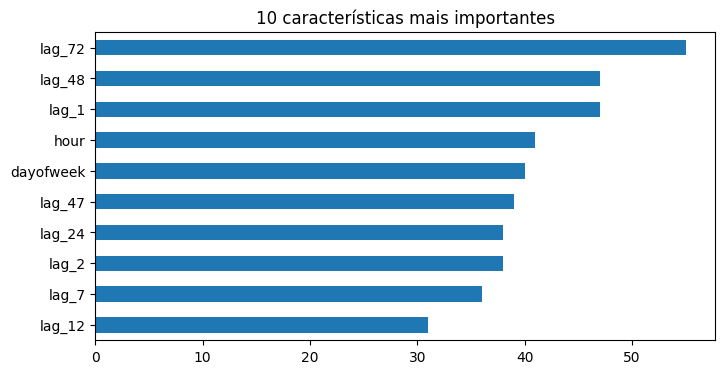

In [18]:
importancias = pd.Series(
    melhor_modelo.feature_importances_, index=features_train.columns
).sort_values(ascending=False)

importancias.head(10).sort_values().plot(
    kind='barh', figsize=(8, 4), title='10 características mais importantes'
)
plt.show()

As defasagens de 24, 48 e 72 horas aparecem entre as mais usadas, ao lado de `lag_1`, `hour` e `dayofweek`. O modelo se apoia tanto na hora imediatamente anterior quanto no mesmo horário de dias anteriores, o que corresponde aos dois padrões identificados na análise: a dependência de curto prazo e o ciclo diário.

## Conclusão

Os dados de pedidos de táxi (março a agosto de 2018, registros a cada 10 minutos) foram reamostrados em intervalos de uma hora, somando os pedidos de cada intervalo. A série não tinha valores ausentes, duplicatas nem problemas de ordenação.

A análise identificou três padrões. O mais forte é a tendência de crescimento, com a média mensal passando de 57 para 128 pedidos entre março e agosto. O segundo é a sazonalidade diária, com pico à meia-noite (144 pedidos em média) e vale às 6h (25 pedidos). O terceiro, mais fraco, é a variação semanal, com diferenças pequenas entre os dias.

A partir desses padrões, criamos características de calendário (hora, dia da semana, dia, mês), 72 defasagens e uma média móvel de 168 horas. A janela da média móvel foi definida acima da defasagem máxima de propósito, para não gerar uma coluna linearmente dependente das defasagens. A divisão em treinamento e teste manteve a ordem cronológica, com os 10% finais reservados para o teste.

Quatro modelos foram comparados com `GridSearchCV` sobre `TimeSeriesSplit`:

| Modelo | REQM (validação cruzada) | REQM (teste) |
|---|---|---|
| LightGBM | 23.90 | **39.07** |
| Floresta Aleatória | 24.43 | 40.58 |
| Regressão Linear | 24.19 | 41.99 |
| Árvore de Decisão | 28.16 | 47.54 |

O LightGBM (`learning_rate=0.1`, `n_estimators=100`, `num_leaves=15`) foi o melhor modelo, com REQM de 39.07 no conjunto de teste, abaixo do limite de 48 exigido pelo projeto.

O resultado fica bem abaixo das duas referências de sanidade: prever a média constante resulta em REQM de 83.98, e prever o valor da hora anterior resulta em 58.86.

A REQM no teste é mais alta que na validação cruzada em todos os modelos. A explicação está na própria série: o teste corresponde à segunda metade de agosto, o período de maior volume e maior variabilidade absoluta. Como a REQM é medida em número de pedidos, um período com médias mais altas produz erros maiores em valor absoluto, mesmo com a mesma qualidade relativa de previsão.

Na prática, o modelo antecipa a demanda da próxima hora com erro médio em torno de 39 pedidos, o suficiente para orientar a convocação de motoristas nos horários de pico, sobretudo na madrugada, quando a demanda é mais alta.

# Revisão da checklist

- [x]  O Jupyter Notebook está aberto.
- [x]  O código está livre de erros
- [x]  As células com o código foram organizadas em ordem de execução.
- [x]  Os dados foram baixados e preparados
- [x]  Os dados foram analisados
- [x]  O modelo foi treinado e os hiperparâmetros foram selecionados
- [x]  O modelo foi avaliado. Uma conclusão foi fornecida
- [x]  O REQM para o conjunto de teste não é maior que 48